# Aggregazione Auto per Regione
Script per aggregare i dati delle auto per provincia in dati per regione

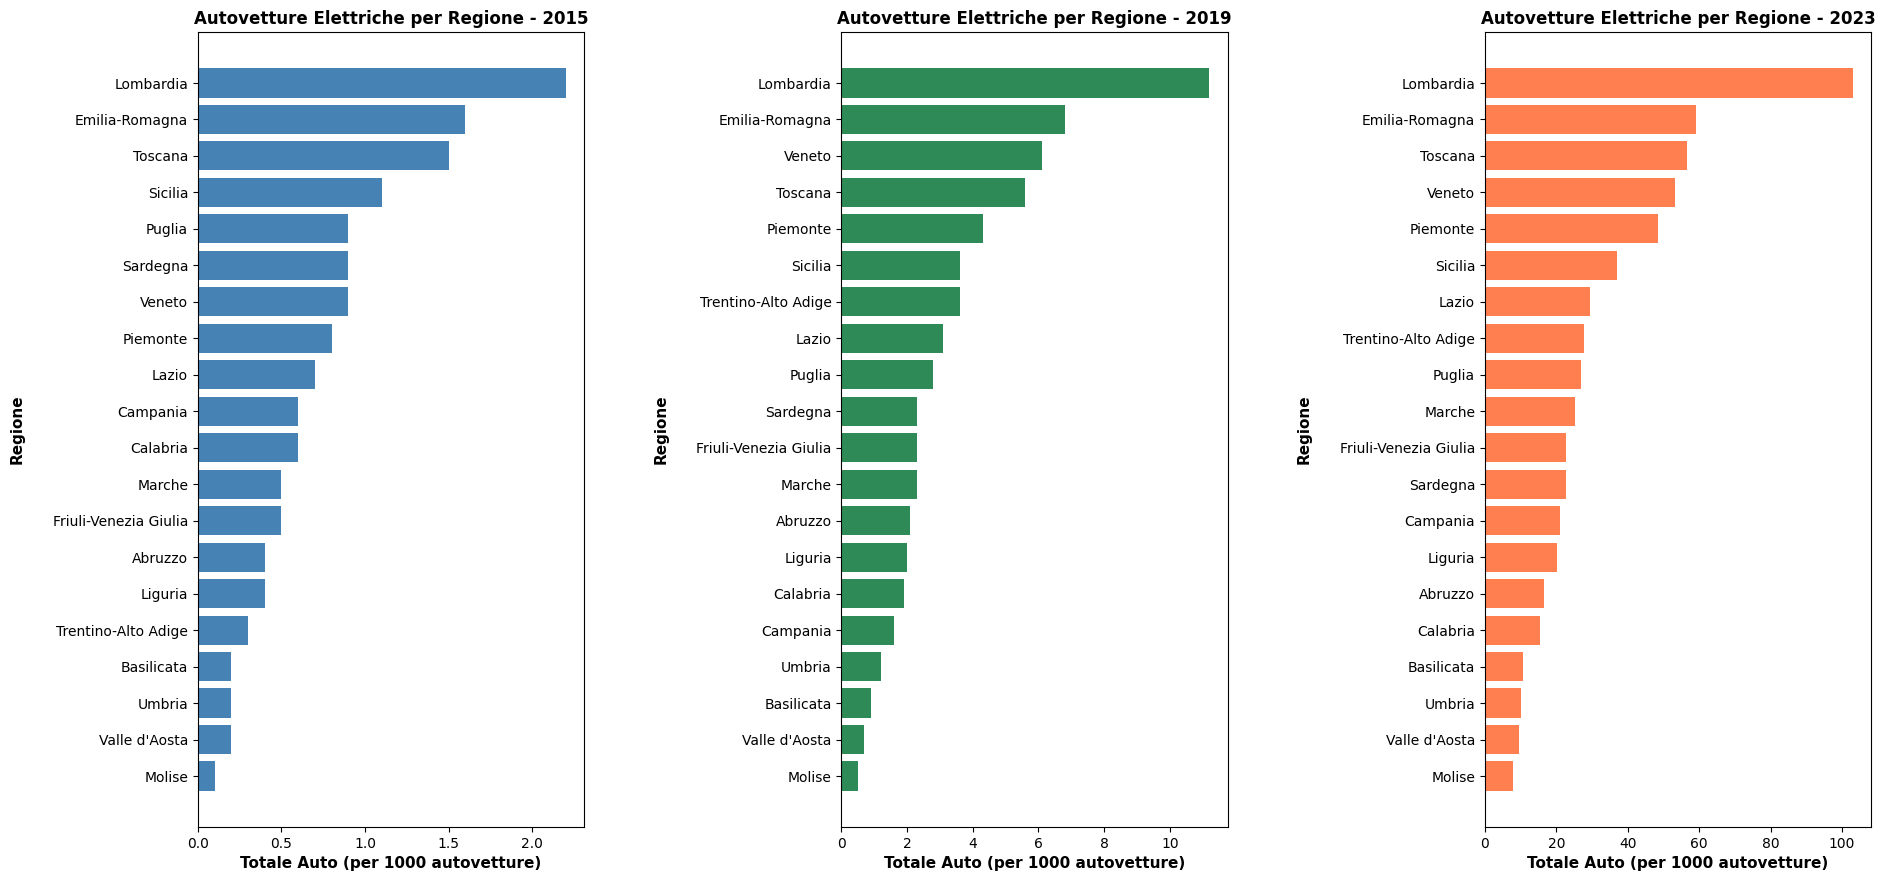

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# CARICA IL CSV
df = pd.read_csv('../data/csv/auto_elettr_su_1000.csv')

# DEFINISCI LISTA DI VALORI DA ESCLUDERE
valori_da_escludere = [
    'Italia', 'Nord', 'Nord-ovest', 'Nord-est', 'Centro', 'Sud', 'Mezzogiorno', 'Isole',
    'Capoluoghi di città metropolitana', 'Capoluoghi di provincia'
]

# FILTRA IL DATAFRAME: mantieni solo le province
df_province = df[~df['Frequenza'].isin(valori_da_escludere)].copy()

# CREA IL MAPPING PROVINCIA -> REGIONE
provincia_regione = {
    # Piemonte
    'Torino': 'Piemonte', 'Vercelli': 'Piemonte', 'Novara': 'Piemonte', 'Cuneo': 'Piemonte',
    'Asti': 'Piemonte', 'Alessandria': 'Piemonte', 'Biella': 'Piemonte', 'Verbania': 'Piemonte',
    
    # Valle d'Aosta
    'Aosta': "Valle d'Aosta",
    
    # Liguria
    'Imperia': 'Liguria', 'Savona': 'Liguria', 'Genova': 'Liguria', 'La Spezia': 'Liguria',
    
    # Lombardia
    'Varese': 'Lombardia', 'Como': 'Lombardia', 'Lecco': 'Lombardia', 'Sondrio': 'Lombardia',
    'Milano': 'Lombardia', 'Bergamo': 'Lombardia', 'Brescia': 'Lombardia', 'Pavia': 'Lombardia',
    'Cremona': 'Lombardia', 'Mantova': 'Lombardia', 'Monza': 'Lombardia', 'Lodi': 'Lombardia',
    
    # Trentino-Alto Adige
    'Bolzano/Bozen': 'Trentino-Alto Adige', 'Trento': 'Trentino-Alto Adige',
    
    # Veneto
    'Belluno': 'Veneto', 'Treviso': 'Veneto', 'Venezia': 'Veneto', 'Padova': 'Veneto',
    'Rovigo': 'Veneto', 'Verona': 'Veneto', 'Vicenza': 'Veneto',
    
    # Friuli-Venezia Giulia
    'Pordenone': 'Friuli-Venezia Giulia', 'Udine': 'Friuli-Venezia Giulia',
    'Gorizia': 'Friuli-Venezia Giulia', 'Trieste': 'Friuli-Venezia Giulia',
    
    # Emilia-Romagna
    'Piacenza': 'Emilia-Romagna', 'Parma': 'Emilia-Romagna', 'Reggio nell\'Emilia': 'Emilia-Romagna',
    'Modena': 'Emilia-Romagna', 'Bologna': 'Emilia-Romagna', 'Ferrara': 'Emilia-Romagna',
    'Ravenna': 'Emilia-Romagna', 'Forlì': 'Emilia-Romagna', 'Cesena': 'Emilia-Romagna', 
    'Rimini': 'Emilia-Romagna',
    
    # Toscana
    'Massa': 'Toscana', 'Lucca': 'Toscana', 'Pistoia': 'Toscana', 'Firenze': 'Toscana',
    'Prato': 'Toscana', 'Livorno': 'Toscana', 'Pisa': 'Toscana', 'Arezzo': 'Toscana',
    'Siena': 'Toscana', 'Grosseto': 'Toscana',
    
    # Umbria
    'Perugia': 'Umbria', 'Terni': 'Umbria',
    
    # Marche
    'Pesaro': 'Marche', 'Ancona': 'Marche', 'Macerata': 'Marche', 'Ascoli Piceno': 'Marche',
    'Fermo': 'Marche',
    
    # Lazio
    'Viterbo': 'Lazio', 'Rieti': 'Lazio', 'Roma': 'Lazio', 'Frosinone': 'Lazio', 'Latina': 'Lazio',
    
    # Abruzzo
    'L\'Aquila': 'Abruzzo', 'Teramo': 'Abruzzo', 'Pescara': 'Abruzzo', 'Chieti': 'Abruzzo',
    
    # Molise
    'Campobasso': 'Molise', 'Isernia': 'Molise',
    
    # Campania
    'Caserta': 'Campania', 'Benevento': 'Campania', 'Napoli': 'Campania', 'Avellino': 'Campania',
    'Salerno': 'Campania',
    
    # Puglia
    'Foggia': 'Puglia', 'Bari': 'Puglia', 'Taranto': 'Puglia', 'Brindisi': 'Puglia',
    'Lecce': 'Puglia', 'Andria': 'Puglia', 'Barletta': 'Puglia', 'Trani': 'Puglia',
    
    # Basilicata
    'Potenza': 'Basilicata', 'Matera': 'Basilicata',
    
    # Calabria
    'Cosenza': 'Calabria', 'Catanzaro': 'Calabria', 'Reggio di Calabria': 'Calabria',
    'Crotone': 'Calabria', 'Vibo Valentia': 'Calabria',
    
    # Sicilia
    'Palermo': 'Sicilia', 'Trapani': 'Sicilia', 'Agrigento': 'Sicilia', 'Caltanissetta': 'Sicilia',
    'Enna': 'Sicilia', 'Catania': 'Sicilia', 'Ragusa': 'Sicilia', 'Siracusa': 'Sicilia',
    'Messina': 'Sicilia',
    
    # Sardegna
    'Sassari': 'Sardegna', 'Nuoro': 'Sardegna', 'Oristano': 'Sardegna', 'Cagliari': 'Sardegna',
    'Carbonia': 'Sardegna',
}

# AGGIUNGI COLONNA REGIONE
df_province['Regione'] = df_province['Frequenza'].map(provincia_regione)

# FILTRA: mantieni solo le righe con regione mappata
df_con_regioni = df_province[df_province['Regione'].notna()].copy()

# CONVERTI INDICATORE A NUMERICO
df_con_regioni['Valore_Numerico'] = pd.to_numeric(df_con_regioni['Indicatore'], errors='coerce')

# CREA DATAFRAME PER OGNI ANNO (2015, 2019, 2023)
df_2015 = df_con_regioni[df_con_regioni['DATA_TYPE'] == 2015].groupby('Regione')['Valore_Numerico'].sum().reset_index()
df_2015.columns = ['Regione', 'Totale_Auto']
df_2015 = df_2015.sort_values('Totale_Auto', ascending=False)

df_2019 = df_con_regioni[df_con_regioni['DATA_TYPE'] == 2019].groupby('Regione')['Valore_Numerico'].sum().reset_index()
df_2019.columns = ['Regione', 'Totale_Auto']
df_2019 = df_2019.sort_values('Totale_Auto', ascending=False)

df_2023 = df_con_regioni[df_con_regioni['DATA_TYPE'] == 2023].groupby('Regione')['Valore_Numerico'].sum().reset_index()
df_2023.columns = ['Regione', 'Totale_Auto']
df_2023 = df_2023.sort_values('Totale_Auto', ascending=False)

# CREA I 3 GRAFICI
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# Grafico 2015
axes[0].barh(df_2015['Regione'], df_2015['Totale_Auto'], color='steelblue')
axes[0].set_xlabel('Totale Auto (per 1000 autovetture)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Regione', fontsize=11, fontweight='bold', labelpad=20)
axes[0].set_title('Autovetture Elettriche per Regione - 2015', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Grafico 2019
axes[1].barh(df_2019['Regione'], df_2019['Totale_Auto'], color='seagreen')
axes[1].set_xlabel('Totale Auto (per 1000 autovetture)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Regione', fontsize=11, fontweight='bold', labelpad=20)
axes[1].set_title('Autovetture Elettriche per Regione - 2019', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

# Grafico 2023
axes[2].barh(df_2023['Regione'], df_2023['Totale_Auto'], color='coral')
axes[2].set_xlabel('Totale Auto (per 1000 autovetture)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Regione', fontsize=11, fontweight='bold', labelpad=20)
axes[2].set_title('Autovetture Elettriche per Regione - 2023', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout(pad=5)
plt.show()